In [279]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

#Data loading by use yfinance

df = yf.download("AAPL",start="2015-01-01")
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214893,24.682226,23.776353,24.671151,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
2015-01-07,23.864943,23.964610,23.632383,23.743125,160423600
2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000
...,...,...,...,...,...
2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300
2026-02-26,272.950012,276.109985,270.799988,274.950012,32345100


In [280]:
# To see the index multindex 
print(df.columns)


MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [283]:
# After checking i got that there is multindex problem so to solve it i used next step
#Here index  level 0 was prices andLevel 1 was tacker which was so 
# To remove the multidex the tracker-
df.columns=df.columns.droplevel(1)
#which is same as 
#df.columns=df.columns.get_values(0)

In [285]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

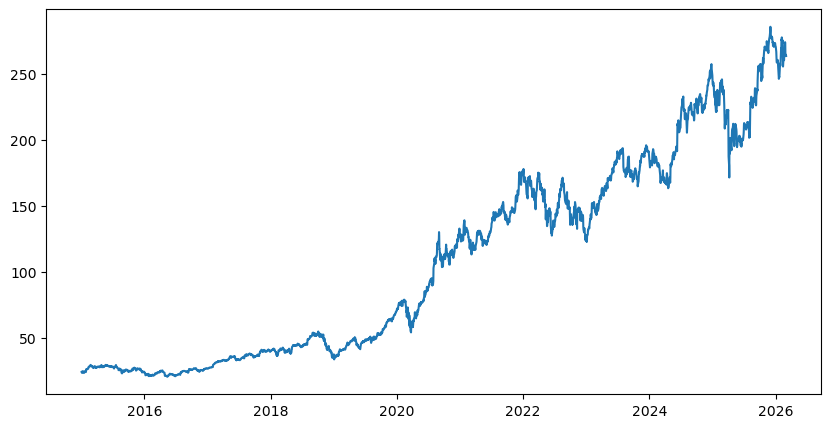

In [287]:


#Closing price trend
plt.plot(df.Close,label="Closing Price")
plt.show()


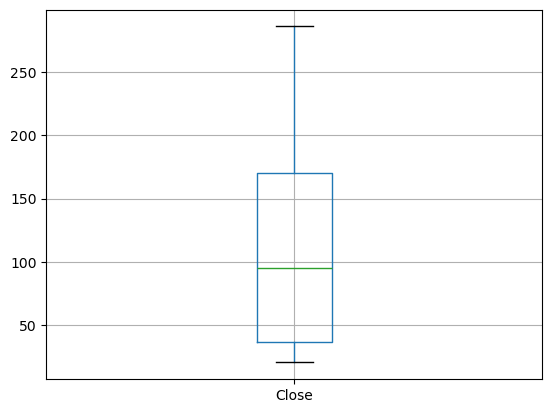

In [289]:
box_plot=df[['Close']].copy().boxplot()
plt.show()

In [291]:
#Whatever we are doing now it is for our model training such that 
#our model can fit correctone model on training dataset and try to give  most correct one prediction
#Now we are calculating Moving Averages (5 and 10, And always remember for rolling means window from 5-1)

df['Return'] = df['Close'].pct_change()


print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-02   24.214893   24.682226   23.776353   24.671151  212818400   
2015-01-05   23.532722   24.064285   23.346676   23.984551  257142000   
2015-01-06   23.534939   23.794075   23.173918   23.596954  263188400   
2015-01-07   23.864943   23.964610   23.632383   23.743125  160423600   
2015-01-08   24.781897   24.839483   24.075361   24.192749  237458000   
...                ...         ...         ...         ...        ...   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   
2026-03-03  263.750000  265.559998  260.130005  263.480011   37994695   

Price         Return  
Date                  
2015

In [293]:
df= df.dropna()
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-05   23.532722   24.064285   23.346676   23.984551  257142000   
2015-01-06   23.534939   23.794075   23.173918   23.596954  263188400   
2015-01-07   23.864943   23.964610   23.632383   23.743125  160423600   
2015-01-08   24.781897   24.839483   24.075361   24.192749  237458000   
2015-01-09   24.808475   25.083116   24.409803   24.954654  214798000   
...                ...         ...         ...         ...        ...   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   
2026-03-03  263.750000  265.559998  260.130005  263.480011   37994695   

Price         Return  
Date                  
2015

In [295]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return'], dtype='object', name='Price')


In [297]:
df = df.copy()
df.loc[:, 'Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.iloc[:-1]
df['MA_5'] = df['Close'].rolling(5).mean().shift(1)
df['MA_10'] = df['Close'].rolling(10).mean().shift(1)


print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-05   23.532722   24.064285   23.346676   23.984551  257142000   
2015-01-06   23.534939   23.794075   23.173918   23.596954  263188400   
2015-01-07   23.864943   23.964610   23.632383   23.743125  160423600   
2015-01-08   24.781897   24.839483   24.075361   24.192749  237458000   
2015-01-09   24.808475   25.083116   24.409803   24.954654  214798000   
...                ...         ...         ...         ...        ...   
2026-02-24  272.140015  274.890015  267.709991  267.859985   47014600   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   

Price         Return  Target        MA_5       MA_

In [299]:
df['Return_lag1'] = df['Return'].shift(1)

In [301]:
df= df.dropna()
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-20   24.079788   24.135159   23.588092   23.884881  199599600   
2015-01-21   24.263617   24.598057   23.980115   24.130725  194303600   
2015-01-22   24.894850   24.910354   24.301271   24.420873  215185600   
2015-01-23   25.023312   25.193854   24.702158   24.872702  185859200   
2015-01-26   25.049891   25.328961   24.983446   25.191640  222460000   
...                ...         ...         ...         ...        ...   
2026-02-24  272.140015  274.890015  267.709991  267.859985   47014600   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   

Price         Return  Target        MA_5       MA_

In [304]:
print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True))

Target
1    1484
0    1311
Name: count, dtype: int64
Target
1    0.530948
0    0.469052
Name: proportion, dtype: float64


In [306]:
def calculate_RSI(data, window=14):
    delta = data['Close'].diff()
    
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

df['RSI'] = calculate_RSI(df)




In [308]:
ema12 = df['Close'].ewm(span=12, adjust=False).mean()

# Long EMA
ema26 = df['Close'].ewm(span=26, adjust=False).mean()

# MACD line
df['MACD'] = ema12 - ema26

# Signal line
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

In [310]:
window = 20

df['MA_20'] = df['Close'].rolling(window=window).mean().shift(1)
df['STD20'] = df['Close'].rolling(window=window).std()

df['Upper_Band'] = df['MA_20'] + (2 * df['STD20'])
df['Lower_Band'] = df['MA_20'] - (2 * df['STD20'])

In [312]:
df['Volatility'] = df['Return'].rolling(window=20).std()

In [314]:
df= df.dropna()
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-02-18   28.622000   28.635341   28.339603   28.379628  179566800   
2015-02-19   28.561954   28.690923   28.535273   28.568625  149449600   
2015-02-20   28.795437   28.795437   28.473018   28.599760  195793600   
2015-02-23   29.573690   29.573690   28.831014   28.911063  283896400   
2015-02-24   29.389130   29.707104   29.166771   29.560347  276912400   
...                ...         ...         ...         ...        ...   
2026-02-24  272.140015  274.890015  267.709991  267.859985   47014600   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   

Price         Return  Target        MA_5       MA_

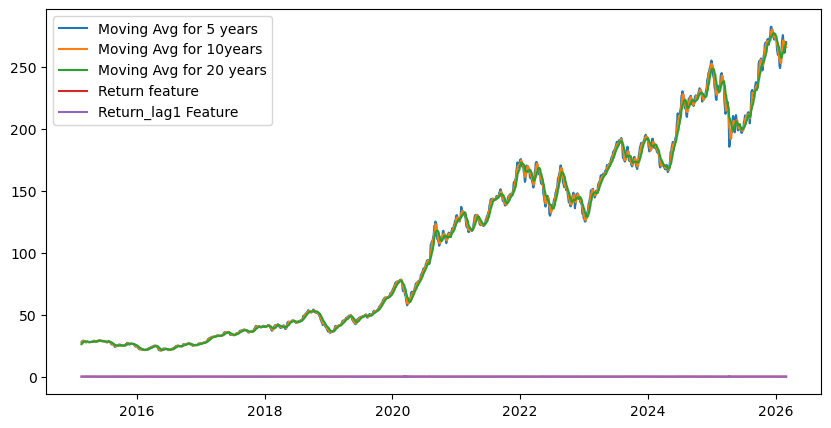

In [316]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.MA_5,label="Moving Avg for 5 years")
plt.plot(df.MA_10,label="Moving Avg for 10years")
plt.plot(df.MA_20,label="Moving Avg for 20 years")

plt.plot(df.Return,label="Return feature")
plt.plot(df.Return_lag1,label="Return_lag1 Feature")

plt.legend()
plt.show()

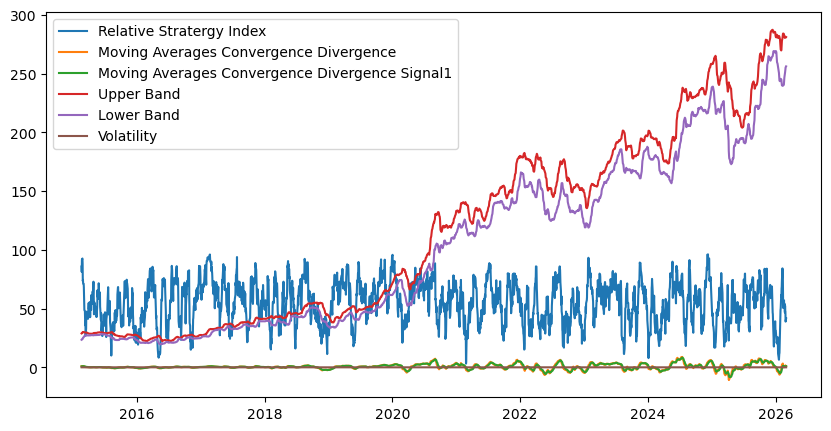

In [318]:
plt.figure(figsize=(10,5))
plt.plot(df.RSI,label="Relative Stratergy Index")
plt.plot(df.MACD,label="Moving Averages Convergence Divergence")
plt.plot(df.MACD_Signal,label="Moving Averages Convergence Divergence Signal1")
plt.plot(df.Upper_Band,label="Upper Band")
plt.plot(df.Lower_Band,label="Lower Band")
plt.plot(df.Volatility,label="Volatility")
plt.legend()
plt.show()


In [320]:
features = ['MA_5', 'MA_10', 'MA_20','Return', 'Return_lag1','RSI', 'MACD', 'MACD_Signal', 
            'Upper_Band', 'Lower_Band', 
            'Volatility']

X = df[features]
y = df['Target']

In [322]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [324]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(pred)


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0
 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 1 1 0 0 0
 0 1 1 1 1 1 1 1 0 0 1 1 

In [326]:
RandomForestClassifier(class_weight='balanced')

RandomForestClassifier(class_weight='balanced')

In [328]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.4774774774774775
              precision    recall  f1-score   support

           0       0.37      0.19      0.25       257
           1       0.51      0.72      0.60       298

    accuracy                           0.48       555
   macro avg       0.44      0.46      0.43       555
weighted avg       0.45      0.48      0.44       555



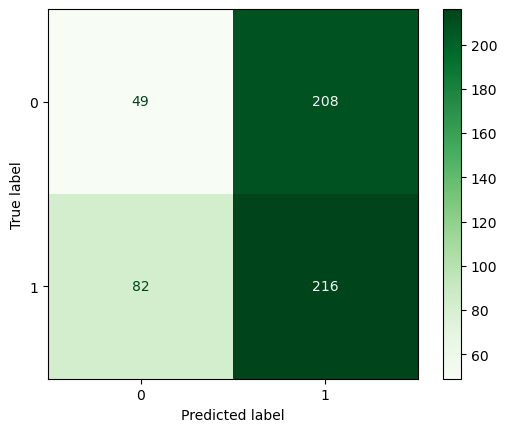

In [330]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.show()

In [333]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)


rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
precision = precision_score(y_test, pred_rf)



print("Precision:", precision)
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Precision: 0.5061728395061729
Accuracy: 0.4648648648648649
              precision    recall  f1-score   support

           0       0.46      0.84      0.59       257
           1       0.51      0.14      0.22       298

    accuracy                           0.46       555
   macro avg       0.48      0.49      0.41       555
weighted avg       0.48      0.46      0.39       555

